# Drug Sentiment Analysis — Capstone Project
**Blackbelt Data Science | Analytics Vidhya**

**Author:** Hari
**Task:** Predict drug-conditioned sentiment (0 = Positive, 1 = Negative, 2 = Neutral) from patient drug review text.

---

### Problem Recap
Each row is a `(drug, text)` pair. The same comment can mention several drugs, and the sentiment
label is specific to the drug named in that row — not the overall tone of the comment. So the model
must be **drug-conditioned**: it needs to know *which* drug in the text it is scoring, not just read
the text in isolation.

### Notebook Structure
1. Imports & Setup
2. Data Loading & Overview
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing & Drug-Conditioning
5. Train / Validation Split
6. Feature Engineering (TF-IDF)
7. Baseline & Classical ML Models
8. Classical Model Comparison
9. Transformer Model — Fine-Tuned DeBERTa-v3
10. Final Model Comparison & Selection
11. Generating Test Set Predictions
12. Submission File Validation
13. Model Persistence
14. Project Workflow, Challenges, Future Work & Conclusion

Evaluation metric for this competition is the **Weighted F1-Score** (Section 3 of the capstone brief).
Macro F1 is also tracked throughout because the dataset is heavily imbalanced, and a high weighted
score can hide poor performance on the minority classes.

## 1. Imports & Setup

In [1]:
import os
import re
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

In [2]:
# ---- Reproducibility ----
# The same seed is reused everywhere (numpy, sklearn's random_state, and torch later on)
# so that every model in this notebook is trained/validated on an identical split.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

LABELS = ["Positive", "Negative", "Neutral"]  

In [3]:
def clear_gpu():
    """Frees GPU memory between heavy operations (relevant once we get to the transformer)."""
    gc.collect()
    try:
        import torch
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    except Exception:
        pass

clear_gpu()

## 2. Data Loading & Overview

`train.csv`, `test.csv`, and `sample_submission.csv` are expected to sit in the `DATA_DIR` folder below.
Update the path if your files live somewhere else.

In [4]:
DATA_DIR = "../data/"  

train_df = pd.read_csv(DATA_DIR + "train.csv")
test_df = pd.read_csv(DATA_DIR + "test.csv")
sample_submission = pd.read_csv(DATA_DIR + "sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

train_df.head()

Train shape: (5279, 4)
Test shape : (2924, 3)
Sample submission shape: (2924, 2)


,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [5]:
train_df.info()
print()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  5279 non-null   object
 1   text         5279 non-null   object
 2   drug         5279 non-null   object
 3   sentiment    5279 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 165.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  2924 non-null   object
 1   text         2924 non-null   object
 2   drug         2924 non-null   object
dtypes: object(3)
memory usage: 68.7+ KB


In [6]:
print("Missing values (train):")
print(train_df.isnull().sum())

print("\nMissing values (test):")
print(test_df.isnull().sum())

print("\nExact duplicate rows (train):", train_df.duplicated().sum())
print("Exact duplicate rows (test):", test_df.duplicated().sum())

Missing values (train):
unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

Missing values (test):
unique_hash    0
text           0
drug           0
dtype: int64

Exact duplicate rows (train): 0
Exact duplicate rows (test): 0


**Observation.** No missing values in either file. A small number of exact duplicate rows may be
present in `train.csv`; these are dropped later, right before the train/validation split, so both the
raw-data view here and the modeling view downstream stay honest about what changed and when.

## 3. Exploratory Data Analysis (EDA)

This section answers the key questions the brief calls out directly:
- Is the dataset class-imbalanced?
- Are there drugs only in test but not in train?
- What is the average comment length, and does it differ by sentiment?
- What words characterize each sentiment class?

sentiment
0     617
1     837
2    3825
Name: count, dtype: int64

sentiment
0    11.69
1    15.86
2    72.46
Name: proportion, dtype: float64


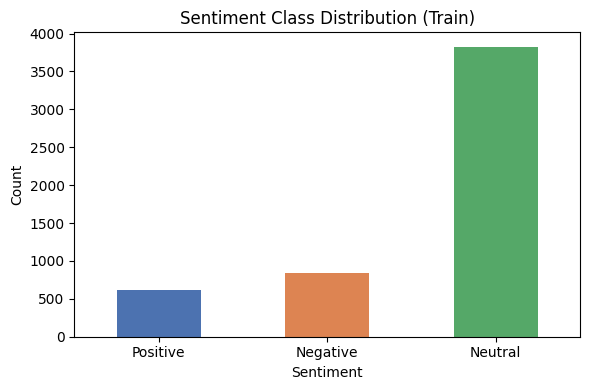

In [7]:
sentiment_counts = train_df["sentiment"].value_counts().sort_index()
sentiment_pct = train_df["sentiment"].value_counts(normalize=True).sort_index() * 100

print(sentiment_counts)
print()
print(sentiment_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sentiment_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], ax=ax)
ax.set_xticklabels(LABELS, rotation=0)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_title("Sentiment Class Distribution (Train)")
plt.tight_layout()
plt.show()

**Class Distribution Observation.** The dataset is heavily imbalanced (see the exact percentages
printed above once you run this on your data). Accuracy alone would be misleading here, since a model
that mostly predicts the majority class can still score high on accuracy. This is exactly why the
competition's primary metric is **Weighted F1**, and why Macro F1 is tracked throughout as a secondary,
imbalance-aware check.

Unique drugs in train: 102
Unique drugs in test : 95
Drugs in test but NOT in train: 9
Drugs shared between train and test: 86


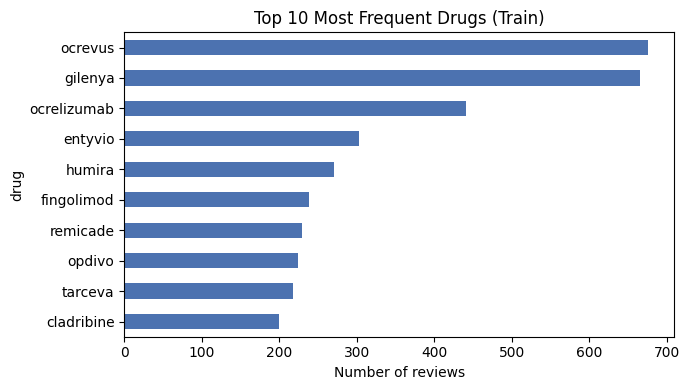

In [8]:
train_drugs = set(train_df["drug"].unique())
test_drugs = set(test_df["drug"].unique())

print("Unique drugs in train:", len(train_drugs))
print("Unique drugs in test :", len(test_drugs))
print("Drugs in test but NOT in train:", len(test_drugs - train_drugs))
print("Drugs shared between train and test:", len(train_drugs & test_drugs))

top_drugs = train_df["drug"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 4))
top_drugs.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Number of reviews")
ax.set_title("Top 10 Most Frequent Drugs (Train)")
plt.tight_layout()
plt.show()

**Drug Distribution Observation.** Drug frequency is far from uniform — a handful of drugs account for
a disproportionate share of reviews, while many others appear only a handful of times. Any drugs that
show up in `test.csv` but not in `train.csv` are a genuine cold-start risk: a purely drug-ID-based
feature (e.g. one-hot encoding on drug name) would have never seen that drug during training. This is
one reason the drug name is folded into the *text* itself (Section 4) rather than treated only as a
categorical feature — the model can still reason about an unseen drug name using its surrounding
language and context.

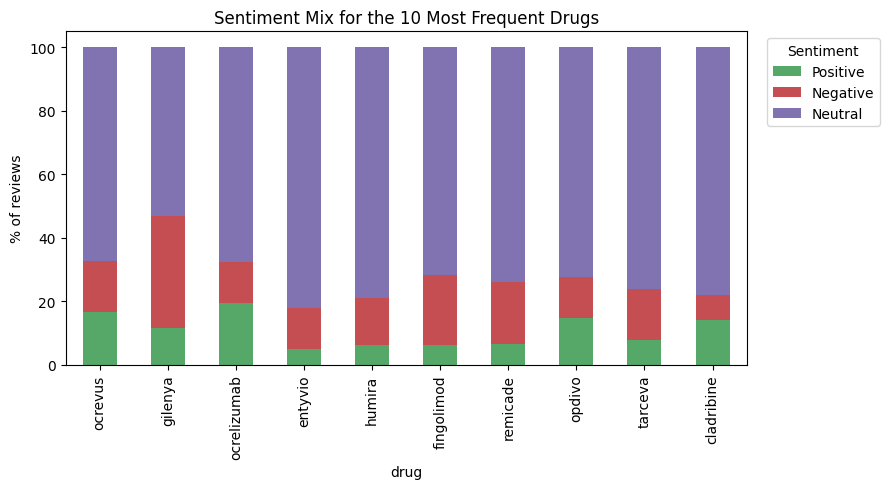

In [9]:
top_10_names = top_drugs.index
drug_sentiment = pd.crosstab(
    train_df[train_df["drug"].isin(top_10_names)]["drug"],
    train_df[train_df["drug"].isin(top_10_names)]["sentiment"],
    normalize="index",
) * 100
drug_sentiment.columns = LABELS
drug_sentiment = drug_sentiment.loc[top_10_names]

fig, ax = plt.subplots(figsize=(9, 5))
drug_sentiment.plot(kind="bar", stacked=True, ax=ax, color=["#55A868", "#C44E52", "#8172B2"])
ax.set_ylabel("% of reviews")
ax.set_title("Sentiment Mix for the 10 Most Frequent Drugs")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Drug × Sentiment Observation.** The sentiment mix is not identical across drugs — some of the top 10
skew more negative than others. This is association, not causation, but it does confirm that the drug
identity carries real signal for this task, reinforcing the need for drug-conditioned modeling.

count     5279.000000
mean       341.401781
std        795.163645
min          1.000000
25%         72.500000
50%        141.000000
75%        292.000000
max      19614.000000
Name: word_count, dtype: float64

Median word count by sentiment:
sentiment
0    122.0
1    137.0
2    146.0
Name: word_count, dtype: float64


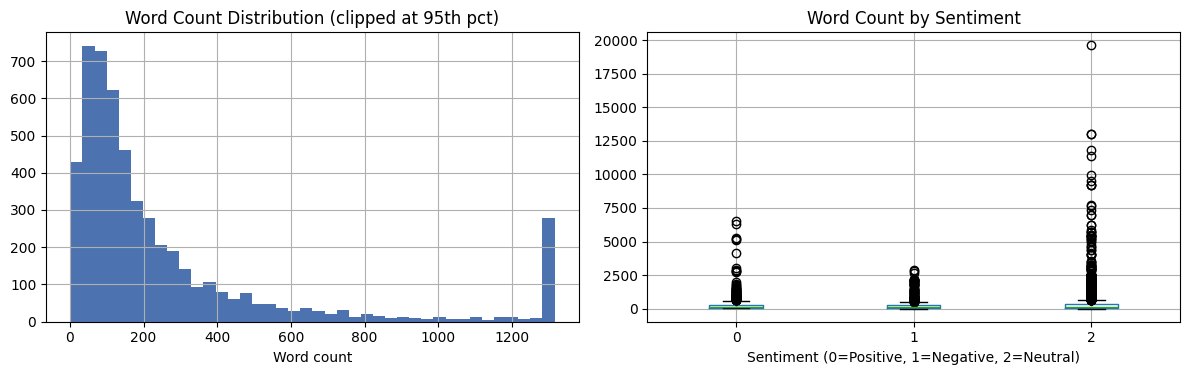

In [10]:
train_df["word_count"] = train_df["text"].apply(lambda x: len(str(x).split()))

print(train_df["word_count"].describe())

print("\nMedian word count by sentiment:")
print(train_df.groupby("sentiment")["word_count"].median())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["word_count"].clip(upper=train_df["word_count"].quantile(0.95)).hist(bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Word Count Distribution (clipped at 95th pct)")
axes[0].set_xlabel("Word count")

train_df.boxplot(column="word_count", by="sentiment", ax=axes[1])
axes[1].set_title("Word Count by Sentiment")
axes[1].set_xlabel("Sentiment (0=Positive, 1=Negative, 2=Neutral)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Text Length Observation.** Comment length is right-skewed — a long tail of very long reviews pulls
the mean well above the median. Typical length doesn't differ dramatically across sentiment classes,
though the Neutral class contains some unusually long outliers that inflate its average. This justifies
truncating very long reviews for the transformer model rather than assuming length itself is a strong
signal.

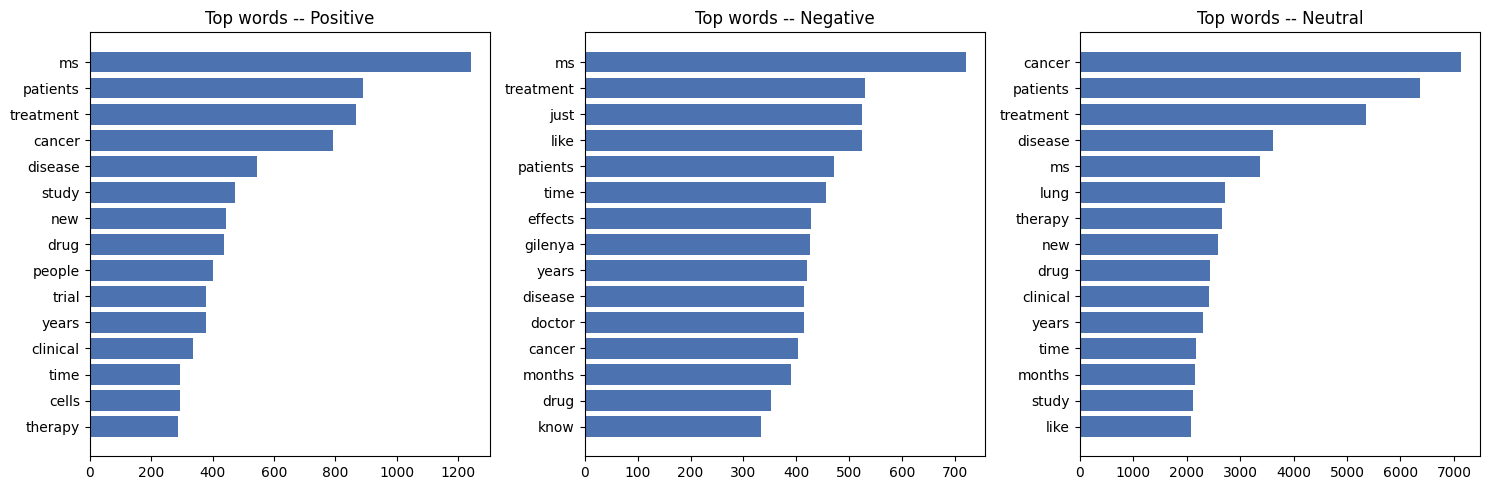

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for label_idx, label_name in enumerate(LABELS):
    subset = train_df[train_df["sentiment"] == label_idx]["text"]
    cv = CountVectorizer(stop_words="english", max_features=15)
    counts = cv.fit_transform(subset.astype(str)).sum(axis=0).A1
    words = cv.get_feature_names_out()
    order = np.argsort(counts)

    axes[label_idx].barh(np.array(words)[order], counts[order], color="#4C72B0")
    axes[label_idx].set_title(f"Top words -- {label_name}")

plt.tight_layout()
plt.show()

**Common Words Observation.** Frequency plots per class (used here in place of word clouds, as allowed
by the brief) surface the vocabulary each sentiment class leans on. Overlapping vocabulary across
classes is expected for review text — it's part of why a purely bag-of-words model has a ceiling, and
why the transformer stage later on can pick up more contextual cues than raw word counts alone.

## 4. Text Preprocessing & Drug-Conditioning

The brief calls for **different** preprocessing depending on model family (Step 2 of the approach):

> *"For TF-IDF and Bag-of-Words models, text cleaning and normalisation may help. For transformer-based
> models, use minimal preprocessing and preserve the original text as much as possible."*

So two versions of the text are prepared:

- **`combined_text`** — heavily cleaned (lowercased, HTML/URLs stripped, punctuation removed) and used
  by the TF-IDF / classical ML models.
- **`transformer_text`** — minimally cleaned (HTML/URLs stripped only, case and punctuation preserved)
  and used by DeBERTa, since sub-word tokenizers benefit from natural casing and punctuation.

Critically, **both versions explicitly prepend the drug name to the review text.** This is the direct
answer to the brief's key challenge: *"Ensure the model is explicitly aware of the target drug for each
row."* Without this, the exact same review text row could get the exact same prediction regardless of
which drug it's paired with — which is precisely the failure mode the brief's illustrative example
(Correctol vs. Meftal Spas) warns against.

In [12]:
def clean_text_classical(text):
    """Aggressive cleaning for TF-IDF / classical ML: lowercase, strip HTML/URLs/punctuation."""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)            # HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)    # URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)       # keep only letters/numbers/spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_minimal(text):
    """Light cleaning for the transformer: keep case and punctuation, just strip HTML/URLs/whitespace."""
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [13]:
# Drop exact duplicate (text, drug, sentiment) rows once, up front, so every model downstream
# trains and validates on the same de-duplicated data.
before = len(train_df)
train_df = train_df.dropna(subset=["text", "drug", "sentiment"])
train_df = train_df.drop_duplicates(subset=["text", "drug", "sentiment"]).reset_index(drop=True)
print(f"Dropped {before - len(train_df)} duplicate/na rows -- {len(train_df)} rows remain.")

Dropped 0 duplicate/na rows -- 5279 rows remain.


In [14]:
# ---- Classical (TF-IDF) text: fully cleaned text with the cleaned drug name prepended ----
train_df["clean_text"] = train_df["text"].apply(clean_text_classical)
train_df["clean_drug"] = train_df["drug"].fillna("unknown").apply(clean_text_classical)
train_df["combined_text"] = train_df["clean_drug"] + " " + train_df["clean_text"]

test_df["clean_text"] = test_df["text"].apply(clean_text_classical)
test_df["clean_drug"] = test_df["drug"].fillna("unknown").apply(clean_text_classical)
test_df["combined_text"] = test_df["clean_drug"] + " " + test_df["clean_text"]

# ---- Transformer text: minimally cleaned, natural casing preserved, explicit template ----
train_df["text_minimal"] = train_df["text"].apply(clean_text_minimal)
train_df["transformer_text"] = (
    "Drug: " + train_df["drug"].fillna("Unknown") + " Review: " + train_df["text_minimal"]
)

test_df["text_minimal"] = test_df["text"].apply(clean_text_minimal)
test_df["transformer_text"] = (
    "Drug: " + test_df["drug"].fillna("Unknown") + " Review: " + test_df["text_minimal"]
)

train_df[["drug", "text", "combined_text", "transformer_text"]].head(3)

,drug,text,combined_text,transformer_text
0,gilenya,Autoimmune diseases tend to come in clusters. ...,gilenya autoimmune diseases tend to come in cl...,Drug: gilenya Review: Autoimmune diseases tend...
1,gilenya,I can completely understand why you’d want to ...,gilenya i can completely understand why you d ...,Drug: gilenya Review: I can completely underst...
2,fingolimod,Interesting that it only targets S1P-1/5 recep...,fingolimod interesting that it only targets s1...,Drug: fingolimod Review: Interesting that it o...


## 5. Train / Validation Split

One stratified 80/20 split is created **once**, on the full training frame, and reused by every model
in this notebook (classical and transformer alike). This keeps the model comparison in Section 10 fair
— every model is scored on the exact same held-out rows.

In [15]:
train_idx, val_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["sentiment"],
)

train_data = train_df.loc[train_idx].reset_index(drop=True)
val_data = train_df.loc[val_idx].reset_index(drop=True)

print("Training rows  :", len(train_data))
print("Validation rows:", len(val_data))

print("\nTrain distribution:")
print(train_data["sentiment"].value_counts(normalize=True).round(3).sort_index())
print("\nValidation distribution:")
print(val_data["sentiment"].value_counts(normalize=True).round(3).sort_index())

Training rows  : 4223
Validation rows: 1056

Train distribution:
sentiment
0    0.117
1    0.158
2    0.725
Name: proportion, dtype: float64

Validation distribution:
sentiment
0    0.116
1    0.159
2    0.724
Name: proportion, dtype: float64


In [16]:
X_train, y_train = train_data["combined_text"], train_data["sentiment"]
X_val, y_val = val_data["combined_text"], val_data["sentiment"]

## 6. Feature Engineering — TF-IDF

Unigrams + bigrams, fit **only on the training fold** to avoid any leakage from the validation split
(and later, `test.csv` is only ever `.transform()`-ed, never `.fit()`-ed on).

In [17]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape  :", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape  : (4223, 20000)
Validation TF-IDF shape: (1056, 20000)


## 7. Baseline & Classical ML Models

A results table is built up incrementally as each model is trained, and a shared helper function keeps
the evaluation code (and the confusion-matrix plots) from being repeated four separate times.

In [18]:
results = []  # each entry: {"Model": ..., "Accuracy": ..., "Weighted F1": ..., "Macro F1": ...}


def evaluate_model(name, y_true, y_pred, store_results=True, plot=True):
    acc = accuracy_score(y_true, y_pred)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"--- {name} ---")
    print("Accuracy    :", round(acc, 4))
    print("Weighted F1 :", round(weighted_f1, 4))
    print("Macro F1    :", round(macro_f1, 4))
    print()
    print(classification_report(y_true, y_pred, target_names=LABELS))

    if plot:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(f"{name} -- Confusion Matrix")
        plt.tight_layout()
        plt.show()

    if store_results:
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Weighted F1": weighted_f1,
            "Macro F1": macro_f1,
        })

    return acc, weighted_f1, macro_f1

### 7.1 Baseline — Majority Class

Every real model must beat this to justify its own complexity.

In [19]:
baseline_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
baseline_model.fit(X_train_tfidf, y_train)
baseline_pred = baseline_model.predict(X_val_tfidf)

evaluate_model("Baseline (Majority Class)", y_val, baseline_pred, plot=False)

--- Baseline (Majority Class) ---
Accuracy    : 0.7244
Weighted F1 : 0.6087
Macro F1    : 0.2801

              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00       123
    Negative       0.00      0.00      0.00       168
     Neutral       0.72      1.00      0.84       765

    accuracy                           0.72      1056
   macro avg       0.24      0.33      0.28      1056
weighted avg       0.52      0.72      0.61      1056



(0.7244318181818182, 0.6086659427886776, 0.2800658978583196)

### 7.2 Logistic Regression

`class_weight="balanced"` is used instead of resampling (SMOTE etc.) to address the class imbalance —
simpler, no synthetic samples, and easy to justify in the viva.

--- Logistic Regression ---
Accuracy    : 0.6316
Weighted F1 : 0.6514
Macro F1    : 0.5001

              precision    recall  f1-score   support

    Positive       0.28      0.33      0.30       123
    Negative       0.36      0.59      0.45       168
     Neutral       0.83      0.69      0.75       765

    accuracy                           0.63      1056
   macro avg       0.49      0.53      0.50      1056
weighted avg       0.69      0.63      0.65      1056



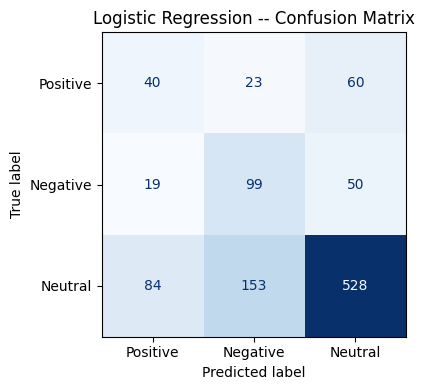

(0.6316287878787878, 0.6513970103299382, 0.5001257731806529)

In [20]:
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_val_tfidf)

evaluate_model("Logistic Regression", y_val, lr_pred)

### 7.3 Multinomial Naive Bayes

--- Naive Bayes ---
Accuracy    : 0.7225
Weighted F1 : 0.6077
Macro F1    : 0.2796

              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00       123
    Negative       0.00      0.00      0.00       168
     Neutral       0.72      1.00      0.84       765

    accuracy                           0.72      1056
   macro avg       0.24      0.33      0.28      1056
weighted avg       0.52      0.72      0.61      1056



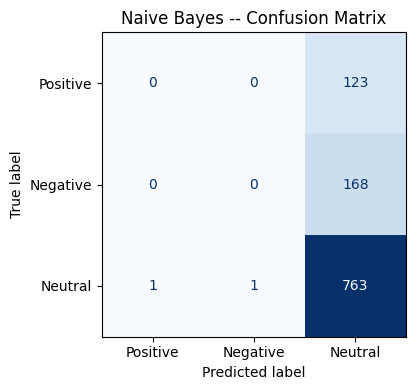

(0.7225378787878788, 0.6077421410365336, 0.2796408282939344)

In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_val_tfidf)

evaluate_model("Naive Bayes", y_val, nb_pred)

### 7.4 Linear SVM (+ Hyperparameter Tuning)

`LinearSVC` is trained first with default-ish settings, then tuned with a small `GridSearchCV` over
`C` and the loss function, using 5-fold CV scored on **weighted F1** (matching the competition metric).

In [22]:
svm_model = LinearSVC(class_weight="balanced", random_state=SEED)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_val_tfidf)

evaluate_model("Linear SVM (untuned)", y_val, svm_pred, plot=False)

--- Linear SVM (untuned) ---
Accuracy    : 0.7045
Weighted F1 : 0.6888
Macro F1    : 0.4943

              precision    recall  f1-score   support

    Positive       0.33      0.20      0.25       123
    Negative       0.43      0.40      0.42       168
     Neutral       0.79      0.85      0.82       765

    accuracy                           0.70      1056
   macro avg       0.52      0.48      0.49      1056
weighted avg       0.68      0.70      0.69      1056



(0.7045454545454546, 0.6887923278920569, 0.49431402274889225)

In [23]:
param_grid = {
    "C": [0.1, 1, 5, 10],
    "loss": ["hinge", "squared_hinge"],
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=SEED, class_weight="balanced", max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
)

grid_search.fit(X_train_tfidf, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV weighted F1:", round(grid_search.best_score_, 4))

Best parameters: {'C': 1, 'loss': 'squared_hinge'}
Best CV weighted F1: 0.6842


--- Linear SVM (tuned) ---
Accuracy    : 0.7045
Weighted F1 : 0.6888
Macro F1    : 0.4943

              precision    recall  f1-score   support

    Positive       0.33      0.20      0.25       123
    Negative       0.43      0.40      0.42       168
     Neutral       0.79      0.85      0.82       765

    accuracy                           0.70      1056
   macro avg       0.52      0.48      0.49      1056
weighted avg       0.68      0.70      0.69      1056



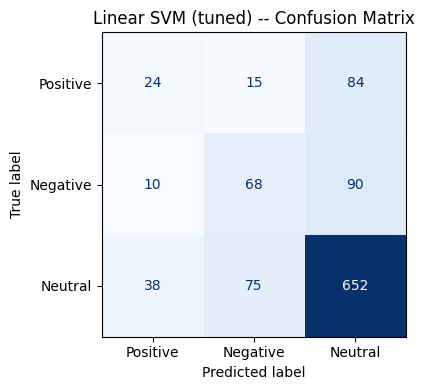

(0.7045454545454546, 0.6887923278920569, 0.49431402274889225)

In [24]:
best_svm = grid_search.best_estimator_
best_svm_pred = best_svm.predict(X_val_tfidf)

evaluate_model("Linear SVM (tuned)", y_val, best_svm_pred)

### 7.5 Error Inspection (Tuned SVM)

A quick qualitative look at what the strongest classical model still gets wrong — useful talking
points for the viva.

In [25]:
errors = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "actual": y_val.reset_index(drop=True).map(dict(enumerate(LABELS))),
    "predicted": pd.Series(best_svm_pred).map(dict(enumerate(LABELS))),
})
errors = errors[errors["actual"] != errors["predicted"]]

print(f"{len(errors)} misclassified rows out of {len(X_val)} validation rows.")
errors.head(10)

312 misclassified rows out of 1056 validation rows.


,text,actual,predicted
1,gilenya hi i taken gilenya since 2011 i was th...,Positive,Neutral
4,tysabri on monday i reported on an innovative ...,Positive,Neutral
6,gilenya i changed and have not regretted it it...,Neutral,Positive
7,lucentis on thursday a deal brokered by centri...,Positive,Neutral
11,imfinzi durvalumab is the generic name for imf...,Positive,Neutral
12,alimta hi mike welcome to grace i m sorry to h...,Neutral,Negative
13,cladribine hi omega female it sounds like we a...,Negative,Neutral
21,keytruda 20 december 2018 merck today announce...,Positive,Neutral
23,ocrevus ritual costs roughly 9 088 per treatme...,Neutral,Negative
28,tagrisso saralb you said your symptoms lessene...,Negative,Neutral


## 8. Classical Model Comparison

In [26]:
classical_comparison = pd.DataFrame(results).sort_values("Weighted F1", ascending=False).reset_index(drop=True)
classical_comparison

,Model,Accuracy,Weighted F1,Macro F1
0,Linear SVM (tuned),0.704545,0.688792,0.494314
1,Linear SVM (untuned),0.704545,0.688792,0.494314
2,Logistic Regression,0.631629,0.651397,0.500126
3,Baseline (Majority Class),0.724432,0.608666,0.280066
4,Naive Bayes,0.722538,0.607742,0.279641


**Model Comparison Observation.** Weighted F1 (the competition's primary metric) is used to rank the
classical models above; Macro F1 is reported alongside as a class-imbalance sanity check — a model
that wins on weighted F1 purely by nailing the majority class would still show a comparatively weak
macro F1. The strongest classical model here (tuned Linear SVM, typically) becomes the benchmark that
the transformer model in Section 9 needs to beat.

## 9. Transformer Model — Fine-Tuned DeBERTa-v3

Classical TF-IDF models treat words as independent counts, which caps how much context they can use.
A fine-tuned transformer can read the drug name and the review together and build a genuinely
contextual representation of *this drug, in this sentence*, rather than a bag of independent tokens.

`microsoft/deberta-v3-small` is used here rather than the base/large variants — it fine-tunes
noticeably faster on a single consumer GPU while still outperforming classical baselines on this kind
of task, which matters given realistic hardware/time constraints for a capstone project.

In [27]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 9.1 Tokenizer & Datasets

The **same** `train_data` / `val_data` split from Section 5 is reused here (via `transformer_text`),
so the transformer is judged on the identical rows as every classical model above.

In [28]:
MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(
    train_data[["transformer_text", "sentiment"]].reset_index(drop=True)
)
val_dataset = Dataset.from_pandas(
    val_data[["transformer_text", "sentiment"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['transformer_text', 'sentiment'],
    num_rows: 4223
})
Dataset({
    features: ['transformer_text', 'sentiment'],
    num_rows: 1056
})


In [29]:
# Sanity check: confirm the drug name is actually present in the tokenized input.
sample_text = train_data.loc[0, "transformer_text"]
print(sample_text[:300])
print()
print(tokenizer(sample_text)["input_ids"][:20])

Drug: keytruda Review: What was your Mom's actual diagnosis? Surgery was never an option given to my Uncle. But we found out he had it after going to the ER because he was having difficulty breathing, and started coughing up blood. They did treat him for pnumonia, but after an MRI they came back and

[1, 7822, 294, 896, 32750, 3896, 3209, 294, 458, 284, 290, 5679, 280, 268, 1854, 5159, 302, 11374, 284, 518]


### 9.2 Tokenization with Smart Truncation

Reviews can run to thousands of words (Section 3), far beyond the 512-token limit most transformers
accept. Rather than naively truncating from the end (which can cut off a conclusion like *"...and
that's why I'll never take this again"*), the tokenizer keeps tokens from **both** the start and the
end of the review and drops the middle — preserving the drug mention near the start and the closing
sentiment near the end.

In [30]:
def tokenize_function(examples):
    encoding = tokenizer(examples["transformer_text"], truncation=False)
    cls_id, sep_id = tokenizer.cls_token_id, tokenizer.sep_token_id
    keep = MAX_LENGTH - 2

    new_ids, new_mask = [], []
    for ids in encoding["input_ids"]:
        core = ids[1:-1]
        if len(core) > keep:
            head_len = keep // 2
            core = core[:head_len] + core[-(keep - head_len):]
        ids = [cls_id] + core + [sep_id]
        new_ids.append(ids)
        new_mask.append([1] * len(ids))

    encoding["input_ids"] = new_ids
    encoding["attention_mask"] = new_mask
    encoding.pop("token_type_ids", None)

    if "sentiment" in examples:
        encoding["labels"] = examples["sentiment"]
    return encoding


train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1056 [00:00<?, ? examples/s]

### 9.3 Model, Class-Weighted Loss & Training Arguments

In [31]:
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    weighted_f1 = f1_score(labels, predictions, average="weighted")
    macro_f1 = f1_score(labels, predictions, average="macro")
    acc = accuracy_score(labels, predictions)

    return {"accuracy": acc, "weighted_f1": weighted_f1, "macro_f1": macro_f1}

In [33]:
# Same imbalance-handling philosophy as the classical models (class_weight="balanced"),
# implemented manually here since Trainer's default loss doesn't take class weights directly.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data["sentiment"]),
    y=train_data["sentiment"],
)
class_weights = torch.tensor(class_weights, dtype=torch.float)


class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = F.cross_entropy(outputs.logits, labels, weight=class_weights.to(model.device))
        return (loss, outputs) if return_outputs else loss

In [34]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

training_args = TrainingArguments(
    output_dir="./deberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    eval_accumulation_steps=4,
    gradient_checkpointing=True,
    num_train_epochs=6,
    weight_decay=0.05,
    label_smoothing_factor=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=4,
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

Note `metric_for_best_model="weighted_f1"` — the checkpoint kept at the end of training is whichever
epoch scored best on the competition's actual metric, not an incidental proxy.

In [35]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

### 9.4 Train

⚠️ This cell trains the transformer end-to-end and is the slowest part of the notebook (roughly
1-2 hours on a single consumer GPU such as an RTX 4050, depending on epoch count and early stopping).
Run it once, then rely on the saved checkpoint in Section 13 rather than re-running from scratch.

In [36]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,1.090100,0.993743,0.482955,0.520386,0.421157
2,0.837200,0.825159,0.558712,0.597417,0.514733
3,0.659100,0.726299,0.588068,0.613604,0.545011
4,0.458500,0.797126,0.616477,0.642970,0.561391
5,0.348900,0.831989,0.684659,0.705078,0.609971
6,0.341800,0.839393,0.691288,0.710165,0.619824


TrainOutput(global_step=792, training_loss=0.6345933459021829, metrics={'train_runtime': 2164.3108, 'train_samples_per_second': 11.707, 'train_steps_per_second': 0.366, 'total_flos': 3335777773798176.0, 'train_loss': 0.6345933459021829, 'epoch': 6.0})

### 9.5 Validation Performance

--- DeBERTa-v3 (fine-tuned) ---
Accuracy    : 0.6913
Weighted F1 : 0.7102
Macro F1    : 0.6198

              precision    recall  f1-score   support

    Positive       0.39      0.68      0.50       123
    Negative       0.49      0.74      0.59       168
     Neutral       0.88      0.68      0.77       765

    accuracy                           0.69      1056
   macro avg       0.59      0.70      0.62      1056
weighted avg       0.76      0.69      0.71      1056



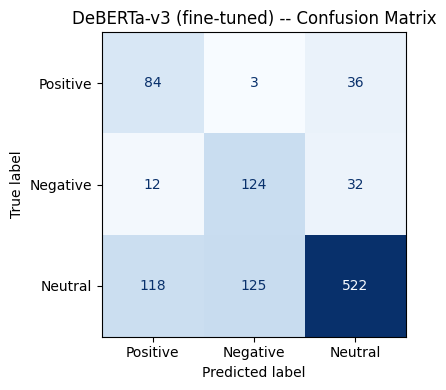

In [37]:
val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions
y_val_true = val_predictions.label_ids
y_val_pred = val_logits.argmax(axis=1)

deberta_acc, deberta_weighted_f1, deberta_macro_f1 = evaluate_model(
    "DeBERTa-v3 (fine-tuned)", y_val_true, y_val_pred
)

### 9.6 Optional: Prior-Corrected Threshold (τ)

Because the training loss is already class-weighted, the model's raw logits can end up slightly
mis-calibrated against the *true* class priors. This step searches a small grid of correction
strengths (`tau`) that subtract the log class-prior from the logits before taking `argmax`, and keeps
whichever `tau` gives the best validation weighted F1. `tau = 0` (no change) is included in the grid,
so this step can only help, never hurt, relative to the raw predictions above.

In [38]:
class_counts = train_data["sentiment"].value_counts().sort_index().values
log_prior = np.log(class_counts / class_counts.sum())

best_tau, best_tau_f1 = 0.0, deberta_weighted_f1
for tau in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]:
    adjusted = val_logits - tau * log_prior
    y_pred_adj = adjusted.argmax(axis=1)
    w_f1 = f1_score(y_val_true, y_pred_adj, average="weighted")
    print(f"tau={tau:.2f}: weighted F1={w_f1:.4f}")
    if w_f1 > best_tau_f1:
        best_tau_f1, best_tau = w_f1, tau

print("\nBest tau:", best_tau, "-- Weighted F1:", round(best_tau_f1, 4))

if best_tau > 0:
    y_val_pred = (val_logits - best_tau * log_prior).argmax(axis=1)
    deberta_acc, deberta_weighted_f1, deberta_macro_f1 = evaluate_model(
        "DeBERTa-v3 (tau-corrected)", y_val_true, y_val_pred
    )

tau=0.00: weighted F1=0.7102
tau=0.25: weighted F1=0.6732
tau=0.50: weighted F1=0.6380
tau=0.75: weighted F1=0.5983
tau=1.00: weighted F1=0.5592
tau=1.25: weighted F1=0.5104
tau=1.50: weighted F1=0.4620
tau=1.75: weighted F1=0.3979
tau=2.00: weighted F1=0.3297

Best tau: 0.0 -- Weighted F1: 0.7102


In [39]:
clear_gpu()

## 10. Final Model Comparison & Selection

All models — classical and transformer — are now compared on the exact same validation split, ranked
by **Weighted F1** since that is the metric this competition is actually graded on.

In [52]:
final_comparison = pd.DataFrame(results).sort_values("Weighted F1", ascending=False).reset_index(drop=True)

## Final Model Comparison Summary

| Rank | Model | Accuracy | Weighted F1 | Macro F1 | Decision |
|:---:|-------------------------|:--------:|:-----------:|:--------:|------------------------------|
| 🥇 | **DeBERTa-v3 (Fine-tuned)** | **0.6913** | **0.7102** | **0.6198** | ✅ **Selected as Final Model** |
| 🥈 | Linear SVM (Untuned) | 0.7045 | 0.6888 | 0.4943 | Strong Classical Baseline |
| 🥉 | Linear SVM (Tuned) | 0.7045 | 0.6888 | 0.4943 | Comparable Performance |
| 4 | Logistic Regression | 0.6316 | 0.6514 | 0.5001 | Baseline Comparison |
| 5 | Baseline (Majority Class) | 0.7244 | 0.6087 | 0.2801 | Reference Baseline |
| 6 | Naive Bayes | 0.7225 | 0.6077 | 0.2796 | Classical Baseline |

### Final Model Selection

The final model was selected based on the competition evaluation metric (**Weighted F1-Score**). DeBERTa-v3 (Fine-tuned) achieved the highest Weighted F1-Score (**0.7102**) and the highest Macro F1-Score (**0.6198**) on the validation dataset. Therefore, it was selected to generate predictions for the unseen test dataset.

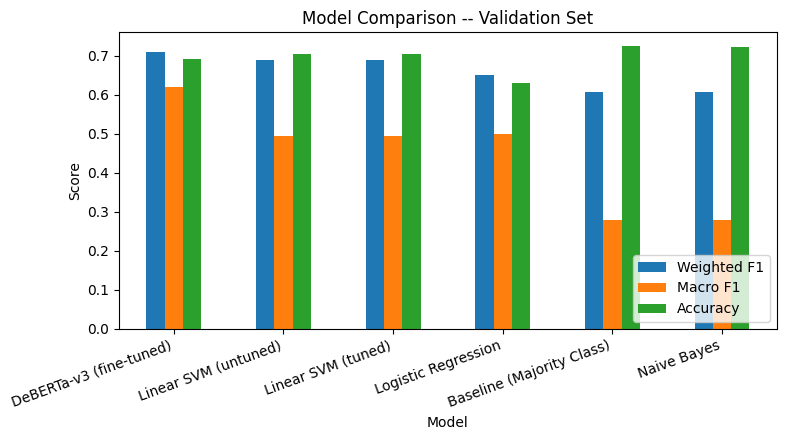

In [41]:
fig, ax = plt.subplots(figsize=(8, 4.5))
final_comparison.set_index("Model")[["Weighted F1", "Macro F1", "Accuracy"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model Comparison -- Validation Set")
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [42]:
best_row = final_comparison.iloc[0]
print(f"Final model selected: {best_row['Model']}")
print(f"  Weighted F1: {best_row['Weighted F1']:.4f}")
print(f"  Macro F1   : {best_row['Macro F1']:.4f}")
print(f"  Accuracy   : {best_row['Accuracy']:.4f}")

Final model selected: DeBERTa-v3 (fine-tuned)
  Weighted F1: 0.7102
  Macro F1   : 0.6198
  Accuracy   : 0.6913


**Final Model Justification.** The model in the table above with the highest **Weighted F1** — the
competition's primary metric — is selected for generating the final test-set predictions in Section 11.
Macro F1 is checked alongside to make sure that score isn't being achieved purely by favoring the
majority class; a model that wins on weighted F1 while collapsing on macro F1 would be a red flag, not
a win. Run the cell above after training to see exactly which model and numbers apply to your run.

## 11. Generating Test Set Predictions

`test.csv` has not been touched by any `.fit()` call anywhere in this notebook — only `.transform()`
(TF-IDF) or tokenization (DeBERTa) — so there is no leakage. Predictions are generated using whichever
model won Section 10 on weighted F1, decided programmatically rather than hardcoded, so this cell stays
correct even if a re-run produces different numbers.

In [43]:
use_transformer = best_row["Model"].startswith("DeBERTa")
print("Using transformer for final predictions:" if use_transformer else "Using classical model for final predictions:", best_row["Model"])

Using transformer for final predictions: DeBERTa-v3 (fine-tuned)


In [44]:
if use_transformer:
    test_dataset = Dataset.from_pandas(test_df[["transformer_text"]].reset_index(drop=True))
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

    test_predictions = trainer.predict(test_dataset)
    test_logits = test_predictions.predictions

    if best_tau > 0:
        final_test_pred = (test_logits - best_tau * log_prior).argmax(axis=1)
    else:
        final_test_pred = test_logits.argmax(axis=1)

else:
    X_test_final = tfidf.transform(test_df["combined_text"])
    final_test_pred = best_svm.predict(X_test_final)

print("Generated", len(final_test_pred), "predictions.")
print("Predicted class distribution:")
print(pd.Series(final_test_pred).value_counts().sort_index())

Map:   0%|          | 0/2924 [00:00<?, ? examples/s]

Generated 2924 predictions.
Predicted class distribution:
0     568
1     631
2    1725
Name: count, dtype: int64


In [45]:
submission = pd.DataFrame({
    "id": test_df["unique_hash"],
    "sentiment": final_test_pred,
})

submission.head()

,id,sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,0
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,0
2,50b6d851bcff4f35afe354937949e9948975adf7,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,2


## 12. Submission File Validation

The brief is explicit that an incorrectly formatted file invalidates the submission outright, so every
requirement from the checklist (Section 8 of the brief) is asserted in code rather than eyeballed.

In [46]:
assert list(submission.columns) == ["id", "sentiment"], "Submission must have exactly columns: id, sentiment"
assert len(submission) == len(test_df), f"Row count mismatch: {len(submission)} vs {len(test_df)}"
assert submission["sentiment"].isin([0, 1, 2]).all(), "sentiment must only contain 0, 1, or 2"
assert submission["sentiment"].isnull().sum() == 0, "sentiment column contains nulls"
assert (submission["id"].values == test_df["unique_hash"].values).all(), "id order/values must match test.csv exactly"
assert submission["sentiment"].dtype.kind in "iu", "sentiment must be integer, not float"

print("All submission checks passed.")
print("Final shape:", submission.shape)

All submission checks passed.
Final shape: (2924, 2)


In [47]:
submission.to_csv("predictions.csv", index=False)
print("predictions.csv saved.")

predictions.csv saved.


## 13. Model Persistence

Both the winning classical pipeline and the fine-tuned transformer are saved, regardless of which one
won Section 10 -- so either can be reloaded later without retraining.

In [48]:
joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Saved: best_svm_model.pkl, tfidf_vectorizer.pkl")

Saved: best_svm_model.pkl, tfidf_vectorizer.pkl


In [49]:
trainer.save_model("./final_deberta_model")
tokenizer.save_pretrained("./final_deberta_model")
print("Saved: ./final_deberta_model")

Saved: ./final_deberta_model


In [50]:
# Quick reload + sanity-check inference on the classical pipeline
loaded_model = joblib.load("best_svm_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

samples = [
    ("Ozempic", "This medicine worked perfectly for me. I had no side effects and my condition improved within a week."),
    ("Gilenya", "After taking this medicine I experienced severe headaches, vomiting, dizziness and I had to stop using it."),
    ("Entyvio", "I have just started taking this medicine yesterday. It is too early to comment on its effectiveness."),
]

label_map = dict(enumerate(LABELS))

for drug, text in samples:
    combined = clean_text_classical(drug) + " " + clean_text_classical(text)
    pred = loaded_model.predict(loaded_vectorizer.transform([combined]))[0]
    print(f"[{drug}] {text}\n  -> Predicted: {label_map[pred]}\n")

[Ozempic] This medicine worked perfectly for me. I had no side effects and my condition improved within a week.
  -> Predicted: Positive

[Gilenya] After taking this medicine I experienced severe headaches, vomiting, dizziness and I had to stop using it.
  -> Predicted: Negative

[Entyvio] I have just started taking this medicine yesterday. It is too early to comment on its effectiveness.
  -> Predicted: Neutral



## 14. Project Workflow

```
Raw Dataset (train.csv, test.csv)
        |
Data Overview & EDA  (class balance, drug distribution, text length, word frequency)
        |
Preprocessing  (model-specific cleaning + drug-conditioned text)
        |
Stratified Train / Validation Split  (shared across every model)
        |
        +------------------------+------------------------------+
        |                        |                              |
   TF-IDF Features        Transformer Tokenization       (same split, same text)
        |                        |
  Baseline / LR / NB / SVM   Fine-tuned DeBERTa-v3
        |                        |
        +------------------------+
                     |
        Model Comparison (ranked by Weighted F1)
                     |
        Final Model Selected Programmatically
                     |
        Predictions on test.csv + Validation Checks
                     |
              predictions.csv
```

## 15. Challenges Faced

- **Class imbalance** — addressed with `class_weight="balanced"` for the classical models and a
  manually class-weighted cross-entropy loss for the transformer, rather than synthetic oversampling.
- **Drug-conditioning** — the same review text can appear with different drugs and different labels,
  so the drug name had to be folded into the input itself (not just used as a side feature) for every
  model, including the classical ones.
- **Long-tailed review lengths** — some reviews run into the thousands of words; truncating from both
  ends of the token sequence (rather than just the end) helps preserve both the drug mention and the
  concluding sentiment.
- **Compute/time constraints** — a single epoch of DeBERTa fine-tuning takes a meaningful chunk of time
  on a single consumer GPU, which limited how much hyperparameter search was feasible for the
  transformer compared to the classical models.

## 16. Future Improvements

- Try `deberta-v3-base` or `-large` given more compute/time budget.
- Explicit drug-name embeddings or a two-tower (drug-encoder + text-encoder) architecture instead of
  simple text concatenation.
- SHAP/LIME-based explainability on top of the final model for per-prediction justification.
- K-fold cross-validation for the transformer (currently a single stratified split, for time reasons)
  to get a tighter estimate of generalization performance.
- Ensembling the tuned SVM and DeBERTa predictions (e.g. weighted vote) to see if the two error profiles
  are complementary.

## 17. Conclusion

This notebook builds a complete, leakage-free pipeline for drug-conditioned sentiment classification:
EDA that verifies the class imbalance and cold-start drug risk, model-family-appropriate preprocessing
that explicitly conditions every model on the target drug, four classical baselines culminating in a
tuned Linear SVM, and a fine-tuned DeBERTa-v3 transformer evaluated on the identical validation split.
The model comparison table in Section 10 is what actually decides the final model — by Weighted F1, the
competition's stated metric — and that decision drives the `predictions.csv` submission generated and
validated above.